# RIM Experiment Analysis - Haptic Velocity

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rim_teleop.data import ExperimentRegistry, load_streams

DATA_DIR = "/home/athena/csirois/data/franka/rim"

registry = ExperimentRegistry(DATA_DIR)

# --- Select run ---
# run = registry.latest()                         # most recent
run = registry.get("run_20260521_155251")     # specific run

print(f"Run: {run.name}  ({run.created_at})")
cfg_iface = run.config["interface"]
print(f"rim_enabled={cfg_iface['rim_enabled']}  "
      f"force_feedback={cfg_iface['force_feedback']}  "
      f"K={cfg_iface['stiffness']}  D={cfg_iface['damping']}  "
      f"contact_surface={cfg_iface['contact_surface']}")

Run: run_20260521_155251  (2026-05-21 15:52:51.431089)
rim_enabled=True  force_feedback=rim  K=1000.0  D=90.0  contact_surface=0.03


In [10]:
streams = load_streams(run)
print("Streams loaded:")
for name, df in streams.items():
    print(f"  {name}: {len(df)} rows | {list(df.columns)}")

# Normalise all timestamps to a shared t=0
t0 = min(df["ts"].min() for df in streams.values())
for df in streams.values():
    df["t"] = df["ts"] - t0

T_MAX = max(df["t"].max() for df in streams.values())
print(f"\nTotal duration: {T_MAX:.1f} s")

Streams loaded:
  haptic: 288471 rows | ['ts', 'leader_pos', 'leader_vel', 'force_cmd', 'rim_interface_force', 'robot_force', 'deadman_active']
  control: 14424 rows | ['ts', 'rim_x', 'interface_force', 'model_stamp_s']
  rim_model: 14424 rows | ['ts', 'M_eff', 'z_i', 'f_eff', 'x', 'v']
  tracking: 14424 rows | ['ts', 'tcp', 'tool_tip', 'rim', 'target']
  rim: 288469 rows | ['ts', 'x_rim', 'v_rim', 'interface_force']
  metrics: 58 rows | ['ts', 'haptic.measured_hz', 'haptic.target_hz', 'haptic.mean_dt_ms', 'haptic.p95_dt_ms', 'haptic.max_dt_ms', 'rim.measured_hz', 'rim.target_hz', 'rim.mean_dt_ms', 'rim.p95_dt_ms', 'rim.max_dt_ms', 'control.measured_hz', 'control.target_hz', 'control.mean_dt_ms', 'control.p95_dt_ms', 'control.max_dt_ms']

Total duration: 288.5 s


---
## Overview — full recording

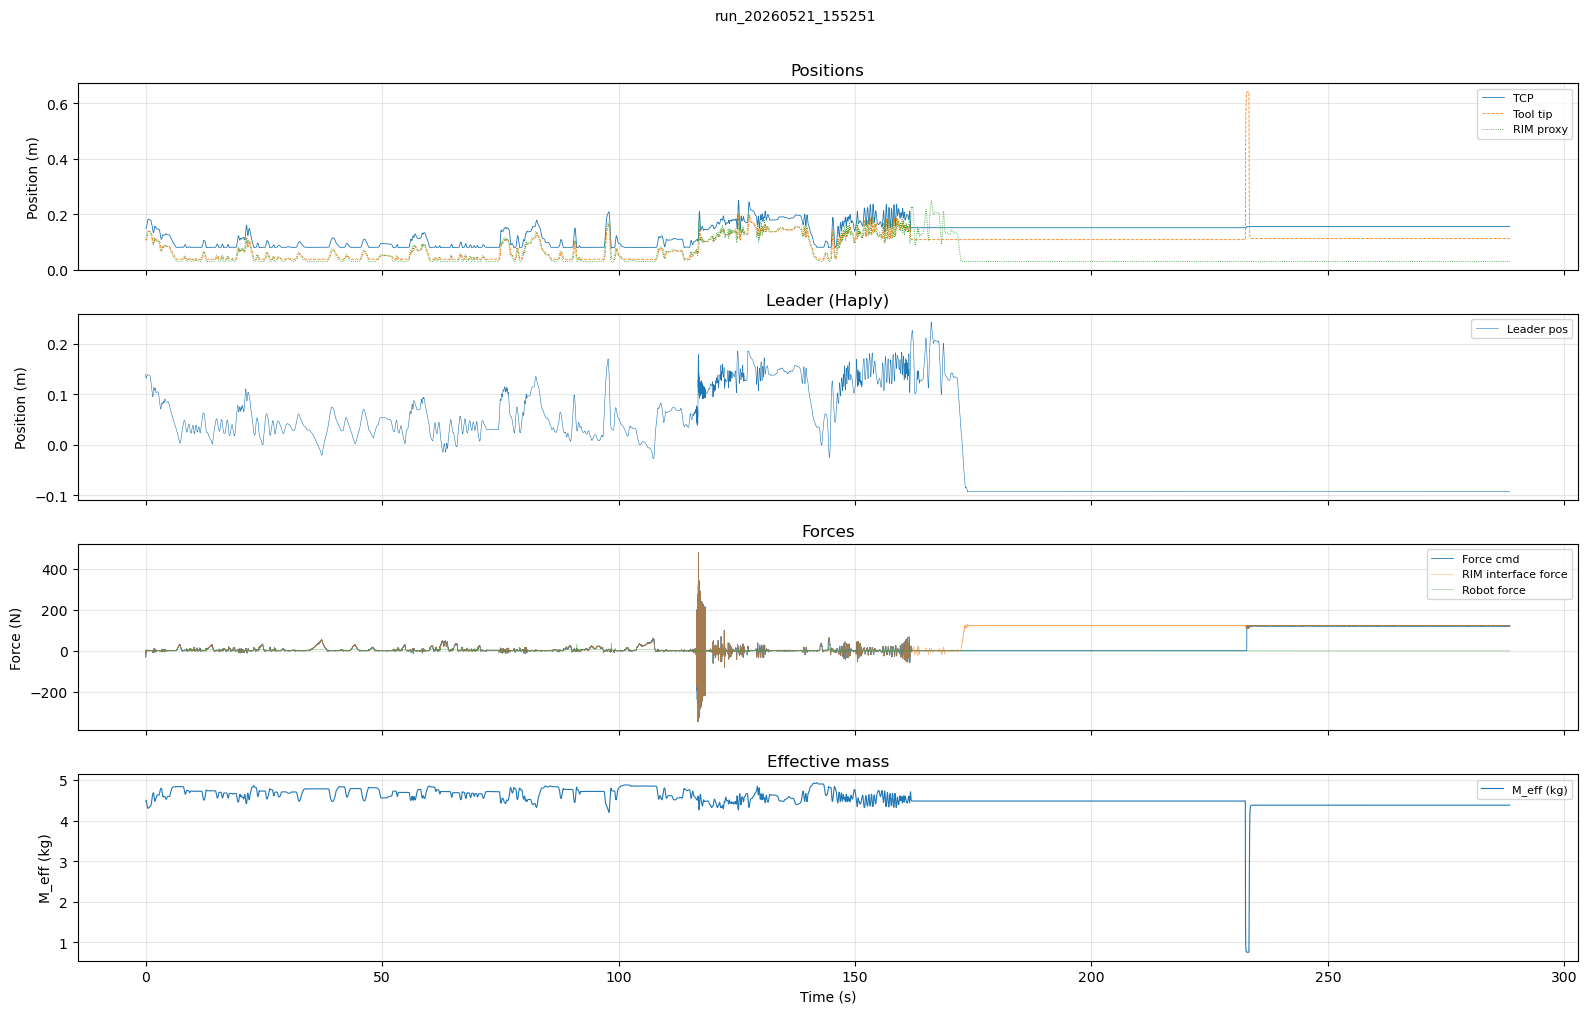

In [11]:
fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)

# — Positions
ax = axes[0]
if "tracking" in streams:
    tr = streams["tracking"]
    ax.plot(tr["t"], tr["tcp"],      lw=0.6, label="TCP")
    ax.plot(tr["t"], tr["tool_tip"], lw=0.6, ls="--", label="Tool tip")
    ax.plot(tr["t"], tr["rim"],      lw=0.6, ls=":",  label="RIM proxy")
ax.set(ylabel="Position (m)", title="Positions")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# — Haptic leader position
ax = axes[1]
if "haptic" in streams:
    hap = streams["haptic"]
    ax.plot(hap["t"], hap["leader_pos"], lw=0.4, label="Leader pos")
ax.set(ylabel="Position (m)", title="Leader (Haply)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# — Forces
ax = axes[2]
if "haptic" in streams:
    ax.plot(hap["t"], hap["force_cmd"],          lw=0.6, label="Force cmd")
    if "rim_interface_force" in hap.columns:
        ax.plot(hap["t"], hap["rim_interface_force"], lw=0.4, alpha=0.6, label="RIM interface force")
    if "robot_force" in hap.columns:
        ax.plot(hap["t"], hap["robot_force"],         lw=0.4, alpha=0.6, label="Robot force")
ax.set(ylabel="Force (N)", title="Forces")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# — RIM model
ax = axes[3]
if "rim_model" in streams:
    rm = streams["rim_model"]
    ax.plot(rm["t"], rm["M_eff"], lw=0.8, label="M_eff (kg)")
ax.set(xlabel="Time (s)", ylabel="M_eff (kg)", title="Effective mass")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle(run.name, fontsize=10, y=1.01)
plt.tight_layout()
plt.show()

---
## Time range selection

Set `T_START` and `T_END` (seconds, normalised) to zoom into a region of interest.
Set either to `None` to keep the full extent.

In [16]:
T_START = 30   # 116
T_END   = 35   # 119

def clip(df: pd.DataFrame, t_start=T_START, t_end=T_END) -> pd.DataFrame:
    """Return rows within [t_start, t_end] (inclusive, None = unbounded)."""
    mask = pd.Series(True, index=df.index)
    if t_start is not None:
        mask &= df["t"] >= t_start
    if t_end is not None:
        mask &= df["t"] <= t_end
    return df[mask]

## Zoomed — haptic device

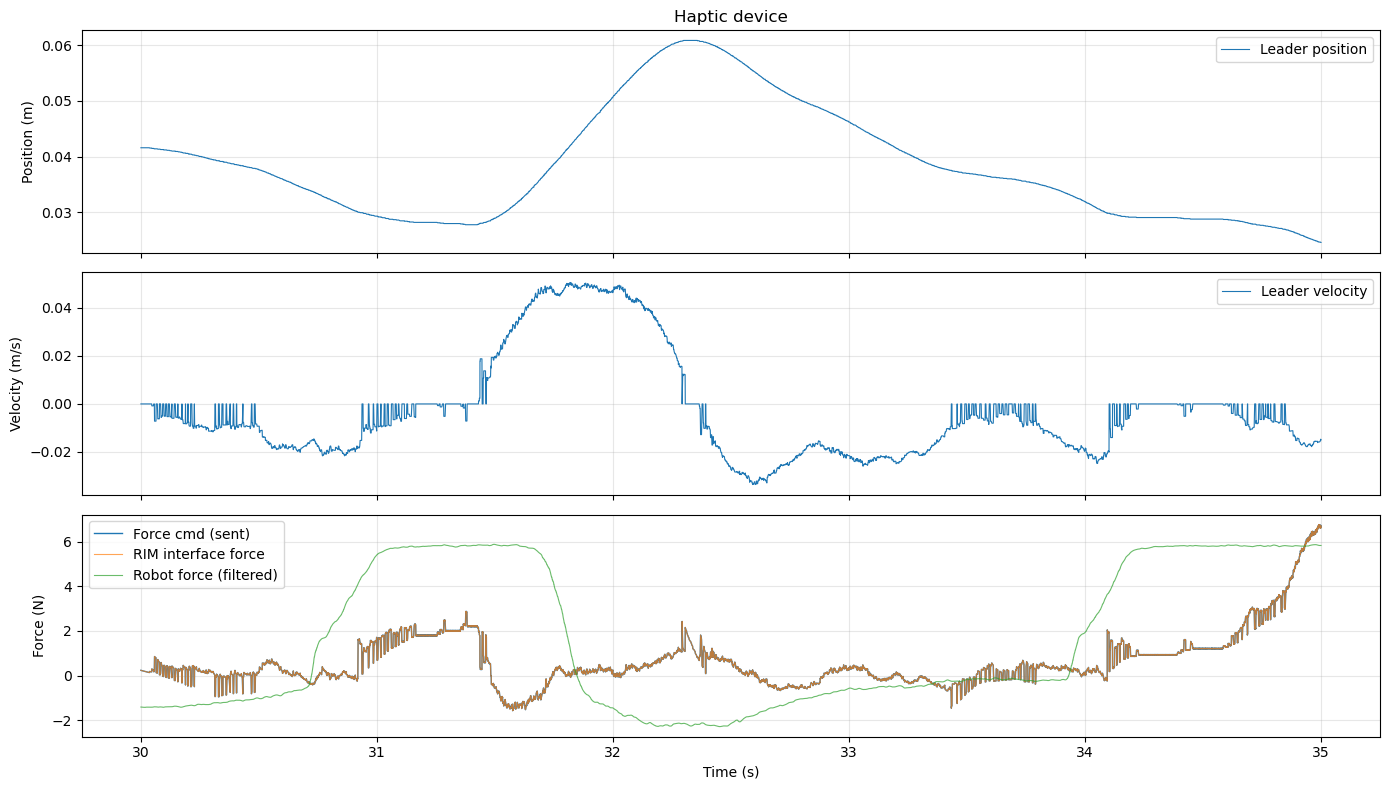

In [17]:
if "haptic" in streams:
    hap = clip(streams["haptic"])
    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

    axes[0].plot(hap["t"], hap["leader_pos"], lw=0.8, label="Leader position")
    axes[0].set(ylabel="Position (m)", title="Haptic device")
    axes[0].legend()

    axes[1].plot(hap["t"], hap["leader_vel"], lw=0.8, label="Leader velocity")
    axes[1].set(ylabel="Velocity (m/s)")
    axes[1].legend()

    axes[2].plot(hap["t"], hap["force_cmd"],          lw=1.0, label="Force cmd (sent)")
    if "rim_interface_force" in hap.columns:
        axes[2].plot(hap["t"], hap["rim_interface_force"], lw=0.8, alpha=0.7, label="RIM interface force")
    if "robot_force" in hap.columns:
        axes[2].plot(hap["t"], hap["robot_force"],         lw=0.8, alpha=0.7, label="Robot force (filtered)")
    axes[2].set(xlabel="Time (s)", ylabel="Force (N)")
    axes[2].legend()

    for ax in axes:
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()